In [2]:
import pandas as pd
df = pd.read_csv("Placement_Data_Full_Class.csv")


DATA OVERVIEW

In [3]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


DATA STRUCTURE

In [4]:
df.shape

(215, 15)

DATA VALUES INFO

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


DATASET NULL VALUES

In [6]:
df.isnull().sum()

,0
sl_no,0
gender,0
ssc_p,0
ssc_b,0
hsc_p,0
hsc_b,0
hsc_s,0
degree_p,0
degree_t,0
workex,0


In [7]:
df['status'].value_counts()

,count
status,
Placed,148
Not Placed,67


CATEGORICAL V

In [8]:
df.nunique()

,0
sl_no,215
gender,2
ssc_p,103
ssc_b,2
hsc_p,97
hsc_b,2
hsc_s,3
degree_p,89
degree_t,3
workex,2


CHK ACTUAL VALUES IN NON NUMERICAL VALUED COLUMNS

In [9]:
for column in df.select_dtypes(include='object').columns:
    print(column, ":", df[column].unique())


gender : ['M' 'F']
ssc_b : ['Others' 'Central']
hsc_b : ['Others' 'Central']
hsc_s : ['Commerce' 'Science' 'Arts']
degree_t : ['Sci&Tech' 'Comm&Mgmt' 'Others']
workex : ['No' 'Yes']
specialisation : ['Mkt&HR' 'Mkt&Fin']
status : ['Placed' 'Not Placed']


STATISTICAL TERMS FOR NUMERICAL VAR

In [10]:
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


CHK FOR DUPLICATE ROWS

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
X = df.drop(columns=['sl_no', 'salary', 'status'])

y = df['status'].map({
    'Placed': 1,
    'Not Placed': 0
})
#here X and y are taken to be the variables by convention in ml programs hence i chose them only

In [13]:
X.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50


In [14]:

y.head()

,status
0,1
1,1
2,1
3,0
4,1


SPLITTING THE DATASET

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#the X and y in LHS are written like this only while on RHS variables are written

CHECKING THE SPLIT

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(172, 12)
(43, 12)
(172,)
(43,)


PD IDENTIFYING THE NUMERICAL AND CATEGORICAL FEATURES FROM FEATURES

In [17]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numerical features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

Numerical features: ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']
Categorical features: ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation']


CATEGORICAL TO COMP UNDERSTANDABLE FORMAT USING ONE HOT ENCODING N COLUMN TRANSFORMER


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

ASKING ML MODEL TO TRANS N LEARN FROM TRAINING ONLY N ONLY TRANS THE TEST DATA TO PREVENT DATA LEAKAGE

In [19]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


PREPROCESSING DONE now CHECK

In [20]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(172, 21)
(43, 21)


MODEL ACTUALLY LEARNING FROM THE PREPARED TRAINING DATA

In [21]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000)

FIRST TIME MAKING PREDICTIONS

In [22]:
y_pred_logistic = logistic_model.predict(X_test_processed)

y_pred_logistic

array([1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0])

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:", f1_score(y_test, y_pred_logistic))

Precision: 0.9259259259259259
Recall: 0.8333333333333334
F1 Score: 0.8771929824561403


DECISION TREE

In [24]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

tree_model.fit(X_train_processed, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

PRED OF 2ND MODEL

In [25]:
y_pred_tree = tree_model.predict(X_test_processed)

y_pred_tree

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0])

EVAL OF DECISION TREE

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))

Precision: 0.7878787878787878
Recall: 0.8666666666666667
F1 Score: 0.8253968253968254


In [27]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Precision': [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_tree)
    ],
    'Recall': [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_tree)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree)
    ]
})

results

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.925926,0.833333,0.877193
1,Decision Tree,0.787879,0.866667,0.825397


In [28]:
example_features = X_test.iloc[[0]]

example_features

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p
63,M,61.0,Others,70.0,Others,Commerce,64.0,Comm&Mgmt,No,68.5,Mkt&HR,59.5


In [29]:
example_processed = preprocessor.transform(example_features)

example_prediction = logistic_model.predict(example_processed)[0]

print(
    "Predicted:",
    "Placed" if example_prediction == 1 else "Not Placed"
)

Predicted: Placed


In [30]:
example_actual = y_test.iloc[0]

print(
    "Actual:",
    "Placed" if example_actual == 1 else "Not Placed"
)

Actual: Not Placed


In [31]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['num__ssc_p', 'num__hsc_p', 'num__degree_p', 'num__etest_p',
       'num__mba_p', 'cat__gender_F', 'cat__gender_M',
       'cat__ssc_b_Central', 'cat__ssc_b_Others', 'cat__hsc_b_Central',
       'cat__hsc_b_Others', 'cat__hsc_s_Arts', 'cat__hsc_s_Commerce',
       'cat__hsc_s_Science', 'cat__degree_t_Comm&Mgmt',
       'cat__degree_t_Others', 'cat__degree_t_Sci&Tech', 'cat__workex_No',
       'cat__workex_Yes', 'cat__specialisation_Mkt&Fin',
       'cat__specialisation_Mkt&HR'], dtype=object)

In [32]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
0,num__ssc_p,0.554283
1,num__hsc_p,0.169159
2,num__degree_p,0.149061
17,cat__workex_No,0.071500
15,cat__degree_t_Others,0.033125
4,num__mba_p,0.022872
3,num__etest_p,0.000000
5,cat__gender_F,0.000000
6,cat__gender_M,0.000000
9,cat__hsc_b_Central,0.000000


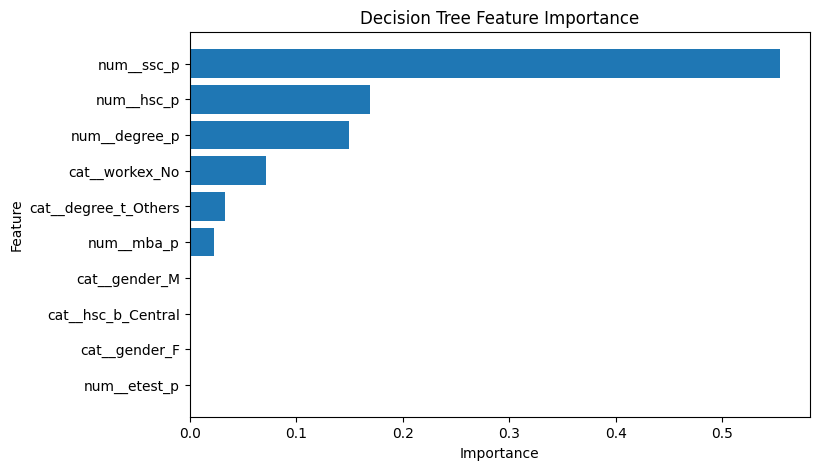

In [33]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10).sort_values(
    'Importance',
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Decision Tree Feature Importance')

plt.show()

In [36]:
results

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.925926,0.833333,0.877193
1,Decision Tree,0.787879,0.866667,0.825397
